In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler



import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from dmba import AIC_score
from dmba import stepwise_selection

no display found. Using non-interactive Agg backend


In [2]:
house = pd.read_csv("data/House_Rent_Dataset.csv")
house.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
# BHK: Number of Bedrooms, Hall, Kitchen.
# Rent: Rent of the Houses/Apartments/Flats.
# Size: Size of the Houses/Apartments/Flats in Square Feet.
# Floor: Houses/Apartments/Flats situated in which Floor and Total Number of Floors (Example: Ground out of 2, 3 out of 5, etc.)
# Area Type: Size of the Houses/Apartments/Flats calculated on either Super Area or Carpet Area or Build Area.
# Area Locality: Locality of the Houses/Apartments/Flats.
# City: City where the Houses/Apartments/Flats are Located.
# Furnishing Status: Furnishing Status of the Houses/Apartments/Flats, either it is Furnished or Semi-Furnished or Unfurnished.
# Tenant Preferred: Type of Tenant Preferred by the Owner or Agent.
# Bathroom: Number of Bathrooms.
# Point of Contact: Whom should you contact for more information regarding the Houses/Apartments/Flats.


In [4]:
house["Tenant Preferred"].value_counts()

Tenant Preferred
Bachelors/Family    3444
Bachelors            830
Family               472
Name: count, dtype: int64

In [5]:
house["Point of Contact"].value_counts()

Point of Contact
Contact Owner      3216
Contact Agent      1529
Contact Builder       1
Name: count, dtype: int64

In [6]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [7]:
house["Posted On"].sort_values()

1222    2022-04-13
244     2022-04-23
418     2022-04-23
303     2022-04-23
413     2022-04-23
           ...    
4368    2022-07-10
4126    2022-07-10
4546    2022-07-10
3743    2022-07-10
3552    2022-07-11
Name: Posted On, Length: 4746, dtype: object

In [8]:
from datetime import datetime

def day_clasificator(date_string):
    date_object = datetime.strptime(date_string, "%Y-%m-%d")
    return date_object.strftime("%A")


house["day_of_week"] = [day_clasificator(date) for date in house["Posted On"].values]
house.sort_values(by="Posted On")

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week
1222,2022-04-13,3,260000,1800,10 out of 11,Carpet Area,JVPD Scheme,Mumbai,Furnished,Family,4,Contact Agent,Wednesday
244,2022-04-23,2,7000,450,1 out of 3,Carpet Area,safuipara,Kolkata,Furnished,Bachelors,2,Contact Owner,Saturday
418,2022-04-23,1,6500,800,Ground out of 1,Carpet Area,Santragachi,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Saturday
303,2022-04-23,2,20000,700,1 out of 2,Super Area,Salt Lake City Sector 1,Kolkata,Furnished,Bachelors/Family,1,Contact Owner,Saturday
413,2022-04-23,3,36125,1700,Ground out of 2,Super Area,Salt Lake City,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4368,2022-07-10,3,95000,2700,23 out of 30,Carpet Area,Gachibowli,Hyderabad,Furnished,Bachelors,3,Contact Agent,Sunday
4126,2022-07-10,3,50000,2300,2 out of 5,Carpet Area,"Ashok Nagar, Himayath Nagar",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday
4546,2022-07-10,3,67000,2310,3 out of 17,Super Area,Madhapur,Hyderabad,Semi-Furnished,Family,3,Contact Agent,Sunday
3743,2022-07-10,3,15000,1200,2 out of 5,Carpet Area,Madambakkam,Chennai,Unfurnished,Bachelors/Family,2,Contact Agent,Sunday


In [9]:
house["Floor2"] = ["0" if text.split(" ")[0] == "Ground" 
                    else "-1" if text.split(" ")[0] == "Upper" or text.split(" ")[0] == "Lower"
                    else  text.split(" ")[0]
                    for text in house.Floor]
house.Floor2.value_counts()

Floor2
1     1161
2      945
0      927
3      512
4      272
5      164
6       93
7       74
10      67
8       66
9       65
12      47
11      43
15      41
-1      34
14      34
18      26
17      22
16      21
19      16
13      15
20      12
25      12
23       9
24       6
21       6
30       5
34       4
28       4
27       3
26       3
32       3
60       3
65       3
35       3
22       3
48       2
53       2
45       2
36       2
40       2
29       1
50       1
49       1
39       1
46       1
41       1
44       1
33       1
37       1
47       1
43       1
76       1
Name: count, dtype: int64

In [10]:
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
        'Bathroom', 'Point of Contact',"day_of_week"]
outcome = "Rent"

x = pd.get_dummies(house[predictors], drop_first=True)

x["Rent"] = house["Rent"]
x

,BHK,Size,Bathroom,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Rent
0,2,1100,2,False,True,False,True,True,False,False,True,False,False,False,False,False,True,10000
1,2,800,1,False,True,True,False,True,False,False,True,False,False,False,False,False,False,20000
2,2,1000,1,False,True,True,False,True,False,False,True,True,False,False,False,False,False,17000
3,2,800,1,False,True,False,True,True,False,False,True,True,False,False,False,False,False,10000
4,2,850,1,True,False,False,True,False,False,False,True,True,False,False,False,False,False,7500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,1000,2,True,False,True,False,True,False,False,True,False,False,False,False,False,True,15000
4742,3,2000,3,False,True,True,False,True,False,False,True,False,False,True,False,False,False,29000
4743,3,1750,3,True,False,True,False,True,False,False,False,False,False,True,False,False,False,35000
4744,3,1500,2,True,False,True,False,False,True,False,False,False,False,False,False,False,True,45000


In [11]:
predictors = ['BHK', 'Size', 'Bathroom', 'Area Type_Carpet Area',
       'Area Type_Super Area', 'Furnishing Status_Semi-Furnished',
       'Furnishing Status_Unfurnished',
       'Tenant Preferred_Bachelors/Family', 'Tenant Preferred_Family',
       'Point of Contact_Contact Builder',
       'Point of Contact_Contact Owner', 'day_of_week_Monday',
       'day_of_week_Saturday', 'day_of_week_Sunday',
       'day_of_week_Thursday', 'day_of_week_Tuesday',
       'day_of_week_Wednesday']
outcome = "Rent"

house_lm = LinearRegression()
house_lm.fit(x[predictors], x[outcome])

floor_residuals = pd.DataFrame({
    "floor_num": house.Floor2,
    "residual": x[outcome] - house_lm.predict(x[predictors])
})

floor_residuals



,floor_num,residual
0,0,-17109.389912
1,1,23476.610858
2,1,14453.149853
3,1,11478.112258
4,1,4096.301492
...,...,...
4741,3,-18296.921923
4742,1,-24793.118990
4743,3,-54585.781518
4744,23,-26385.252620


In [12]:
floor_groups = pd.DataFrame([
    {
        "floor": floor,
        "count": len(i),
        "median_residual": i.residual.median()
    }
    for floor, i in floor_residuals.groupby("floor_num")
]).sort_values("median_residual")

floor_groups.sample()

,floor,count,median_residual
13,2,945,-4891.711341


In [13]:
floor_groups["cum_count"] = np.cumsum(floor_groups["count"])
floor_groups["floor_group"] = pd.qcut(floor_groups.cum_count, 5, labels=False, retbins=False)
floor_groups

,floor,count,median_residual,cum_count,floor_group
17,23,9,-26385.252620,9,0
4,11,43,-11227.678537,52,0
52,9,65,-10503.758004,117,0
9,16,21,-9921.281222,138,0
49,7,74,-8159.644011,212,0
33,4,272,-7944.712120,484,0
43,5,164,-7870.538963,648,0
41,48,2,-7671.308165,650,0
25,30,5,-7626.660934,655,0
3,10,67,-7478.061186,722,0


In [14]:
to_join = floor_groups[["floor", "floor_group"]].set_index("floor")
house = house.join(to_join, on="Floor2")


In [15]:
house["floor_group"] = house["floor_group"].astype("category")

In [16]:
# Extract total floors
house["Total_floors"] = house["Floor"].apply(lambda x: int(x.split(" ")[-1]) if "out of" in x else 1)

# Extract month from Posted On
house["Month"] = pd.to_datetime(house["Posted On"]).dt.month

house

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week,Floor2,floor_group,Total_floors,Month
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Wednesday,0,2,2,5
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Friday,1,1,3,5
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Monday,1,1,3,5
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Monday,1,1,2,7
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,Monday,1,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,Wednesday,3,1,5,5
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,Sunday,1,1,4,5
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday,3,1,5,7
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,Wednesday,23,0,34,7


In [17]:
predictors = ['BHK', 'Size', 'Area Type',
       'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact', 'day_of_week',
       'floor_group','Total_floors',"Month"]
outcome = "Rent"

x = pd.get_dummies(house[predictors], drop_first=True)

train = x.loc[100:]
test = x.loc[0:99]

test["Rent"] = house[outcome].values[0:100]

confounding_lm = LinearRegression()
confounding_lm.fit(x, house[outcome])

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_12253/3272244638.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["Rent"] = house[outcome].values[0:100]


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(x.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 14767.554
Coefficients:
 BHK: 283.96891767027677
 Size: 29.16458930806982
 Bathroom: 13066.501095147716
 Total_floors: 1017.5959172726392
 Month: -3287.3958773959666
 Area Type_Carpet Area: 11685.715652963847
 Area Type_Super Area: 2956.347336100049
 Furnishing Status_Semi-Furnished: -14760.52427068038
 Furnishing Status_Unfurnished: -13176.0845732425
 Tenant Preferred_Bachelors/Family: 3786.798304287755
 Tenant Preferred_Family: -4447.661536613795
 Point of Contact_Contact Builder: -6489.139536556306
 Point of Contact_Contact Owner: -24407.972645799884
 day_of_week_Monday: 2031.468929450638
 day_of_week_Saturday: 2095.3286998066906
 day_of_week_Sunday: -8719.717822878994
 day_of_week_Thursday: -630.390541120074
 day_of_week_Tuesday: 178.53698933709873
 day_of_week_Wednesday: 3223.4474411474794
 floor_group_1: -5767.926447436785
 floor_group_2: -3357.9089605897652
 floor_group_3: 41629.04629581342
 floor_group_4: 90655.41468560442


In [19]:
test_predict = confounding_lm.predict(test.loc[:,x.columns.values])

def adjusted_r2(y_actual, y_predict, p):
    r2 = r2_score(y_actual,y_predict)
    n = y_actual.shape[0]
    print(f"Adjusted r2: {1 - (1 - r2) * ((n - 1) / (n - p - 1))}")

print(f"mse: {mean_squared_error(test.Rent, test_predict)}")
print(f"mae: {mean_absolute_error(test.Rent, test_predict)}")
print(f"r2: {r2_score(test.Rent, test_predict)}")
adjusted_r2(test.Rent, test_predict, 25)

mse: 243015295.42608392
mae: 12630.146145718718
r2: -3.6151996691942676
Adjusted r2: -5.174388746624764


In [20]:
test_predict.min()

np.float64(-14348.174018497582)

In [21]:
# after Feature enginering
#mse: 286855654.62359285
# mae: 12843.389879038397
# r2: -4.447789284226309
# Adjusted: -6.288258637005469


# After handle Outliers

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Calculate metrics for both sets
def print_metrics(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Metrics:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")

# Print metrics for both training and test sets
print_metrics(y_train, train_pred, "Training")
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, 12)

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Training Metrics:
MSE: 4858449595.24
RMSE: 69702.58
MAE: 22760.54
R2 Score: 0.2670

Test Metrics:
MSE: 2115483795.95
RMSE: 45994.39
MAE: 21922.08
R2 Score: 0.4692
Adjusted r2: 0.4623911070415223

Cross-validation scores: [ 0.51581628  0.16185614  0.21878161  0.1778819  -1.1666998 ]
Average CV score: -0.0185 (+/- 1.1769)


In [23]:
# predictors = ['BHK', 'Size',"Bathroom", 'Total_floors',"Price_per_sqft","Month"]
# outcome = "Rent"

# X_train, X_test, y_train, y_test = train_test_split(house[predictors], house[outcome], 
#                                                     test_size=0.2, 
#                                                     random_state=42)

# simple_lm = LinearRegression()
# simple_lm.fit(X_train,y_train)

# # Make predictions
# train_pred = simple_lm.predict(X_train)
# test_pred = simple_lm.predict(X_test)

# print_metrics(y_train, train_pred, "Training")
# print_metrics(y_test, test_pred, "Test")
# adjusted_r2(y_test, test_pred, 3)

In [24]:
def remove_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & 
                           (df_clean[col] <= Q3 + 1.5*IQR)]
    return df_clean

# Remove outliers from numerical columns
numerical_cols = ["Size", "Rent", 'Total_floors',"Month"]
house_clean = remove_outliers(X_test.assign(Rent=y_test), numerical_cols)


In [25]:
# Visualization of predictions vs actual values
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Training Set: Actual vs Predicted')

# Test set
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(12, 5))

# Training residuals
plt.subplot(1, 2, 1)
plt.scatter(train_pred, y_train - train_pred, alpha=0.5)
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Training Set: Residual Plot')

# Test residuals
plt.subplot(1, 2, 2)
plt.scatter(test_pred, y_test - test_pred, alpha=0.5)
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Test Set: Residual Plot')

plt.tight_layout()
plt.show()

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_12253/1350463263.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_12253/1350463263.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [26]:
y_test_clean_pred = model_main.predict(house_clean.drop(axis=1, columns=["Rent"]))
y_test_clean = house_clean.Rent

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test_clean, y_test_clean_pred, alpha=0.5)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_12253/3444030373.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [27]:
print(y_test_clean_pred.min())
print(y_test_clean.min())

-20564.555081949893
1800


In [28]:

numerical_cols = ["Size", "Rent", 'Total_floors',"Month"]
house_clean = remove_outliers(X_train.assign(Rent=y_train), numerical_cols)

y_test_clean_pred = model_main.predict(house_clean.drop(axis=1, columns=["Rent"]))
y_test_clean = house_clean.Rent

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test_clean, y_test_clean_pred, alpha=0.5)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Train Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_12253/1598943089.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [29]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X_train, y_train))

Lasso(alpha=10)


In [30]:

Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

columns = X_train.columns

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X_train, y_train)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X_train, y_train)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient values")
ax.set_title("Lasso coefficient paths")
plt.show()

/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.132e+12, tolerance: 2.516e+09
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.373e+12, tolerance: 2.516e+09
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

In [31]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_, 
})

,name,coef
0,BHK,0.000000
1,Size,42.918120
2,Bathroom,0.000000
3,Total_floors,2182.690158
4,Month,0.000000
5,Area Type_Carpet Area,0.000000
6,Area Type_Super Area,-0.000000
7,Furnishing Status_Semi-Furnished,-0.000000
8,Furnishing Status_Unfurnished,-0.000000
9,Tenant Preferred_Bachelors/Family,-0.000000


In [32]:
print(f'Intercept: {model_main.intercept_:.3f}')

pd.DataFrame({
    "name": X_train.columns,
    "coef": model_main.coef_
})

Intercept: 15399.806


,name,coef
0,BHK,1620.656437
1,Size,25.342627
2,Bathroom,13919.256272
3,Total_floors,1029.024099
4,Month,-2976.441246
5,Area Type_Carpet Area,11496.797920
6,Area Type_Super Area,3117.376426
7,Furnishing Status_Semi-Furnished,-15209.541580
8,Furnishing Status_Unfurnished,-13194.266363
9,Tenant Preferred_Bachelors/Family,2256.648611


In [33]:
print_metrics(y_test, modelCV.predict(X_test), "Train regularization")
adjusted_r2(y_test,modelCV.predict(X_test), 24)


Train regularization Metrics:
MSE: 2266282948.60
RMSE: 47605.49
MAE: 22482.05
R2 Score: 0.4314
Adjusted r2: 0.41659690292082674


In [34]:
print_metrics(y_test, model_main.predict(X_test), "Train main model")
adjusted_r2(y_test,model_main.predict(X_test), 24)


Train main model Metrics:
MSE: 2115483795.95
RMSE: 45994.39
MAE: 21922.08
R2 Score: 0.4692
Adjusted r2: 0.45541672140314204


In [35]:
y_test_clean_pred = model_main.predict(house_clean.drop(axis=1, columns=["Rent"]))
y_test_clean = house_clean.Rent

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test_clean, y_test_clean_pred, alpha=0.5)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_12253/3444030373.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [36]:
y_test_clean_pred = modelCV.predict(house_clean.drop(axis=1, columns=["Rent"]))
y_test_clean = house_clean.Rent

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test_clean, y_test_clean_pred, alpha=0.5)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set after Lasso regularization')

plt.tight_layout()
plt.show()

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_12253/1290266849.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [37]:
house.Rent.min()

np.int64(1200)

In [38]:
# from sklearn.compose import TransformedTargetRegressor
# from sklearn.linear_model import LinearRegression

# # Create a transformer that ensures non-negative predictions
# model_transformed = TransformedTargetRegressor(
#     regressor=LinearRegression(),
#     func=np.exp,       # transform target to exp(y)
#     inverse_func=np.log  # transform predictions back using log
# )


# model_transformed.fit(X_train, y_train)
# train_pred = model_transformed.predict(X_train)
# test_pred = model_transformed.predict(X_test)

In [39]:
X_train

,BHK,Size,Bathroom,Total_floors,Month,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,...,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,floor_group_1,floor_group_2,floor_group_3,floor_group_4
1995,2,950,2,8,5,False,True,True,False,True,...,False,False,False,False,True,False,True,False,False,False
1497,2,800,2,4,6,False,True,True,False,True,...,False,False,False,True,False,False,True,False,False,False
2763,1,545,1,3,6,False,True,False,False,True,...,True,False,False,False,False,False,True,False,False,False
1351,1,465,1,4,7,False,True,True,False,False,...,False,False,False,True,False,False,True,False,False,False
1862,2,900,2,5,7,False,True,False,False,True,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,3,1500,3,2,6,True,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
466,3,1200,2,3,6,False,True,False,True,True,...,True,False,False,False,False,False,True,False,False,False
3092,2,800,2,17,7,True,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
3772,3,3500,3,1,5,True,False,True,False,True,...,False,False,False,False,True,False,False,True,False,False


In [40]:
y_train

1995    23500
1497    10500
2763    19000
1351    20000
1862    17000
        ...  
4426    25000
466     20000
3092    20000
3772    85000
860     25000
Name: Rent, Length: 3796, dtype: int64

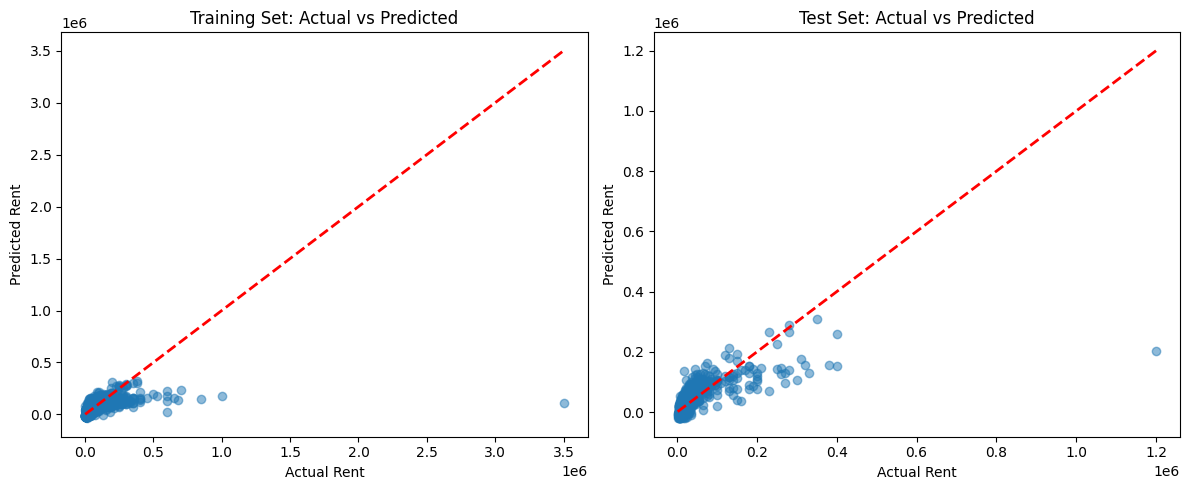

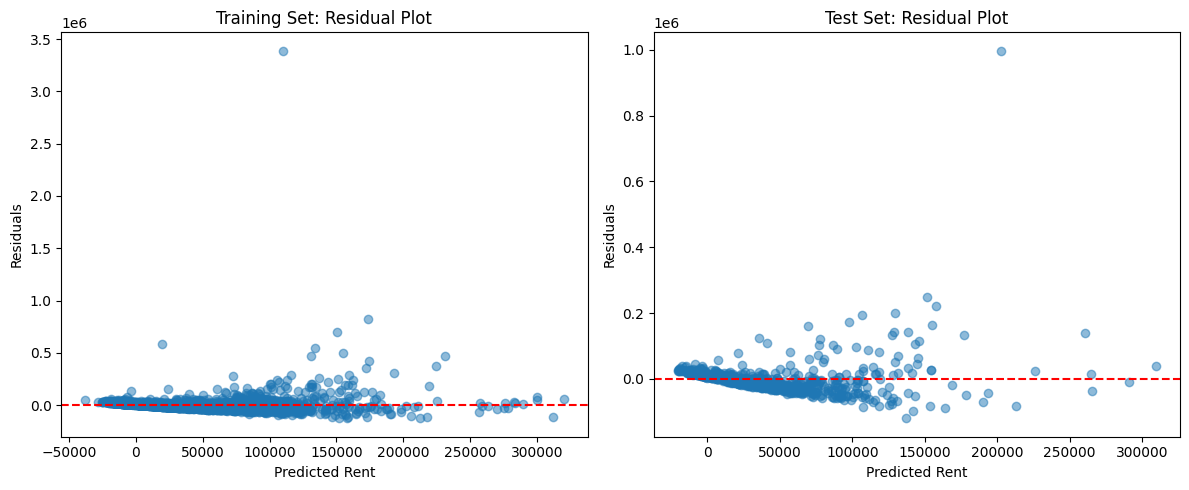

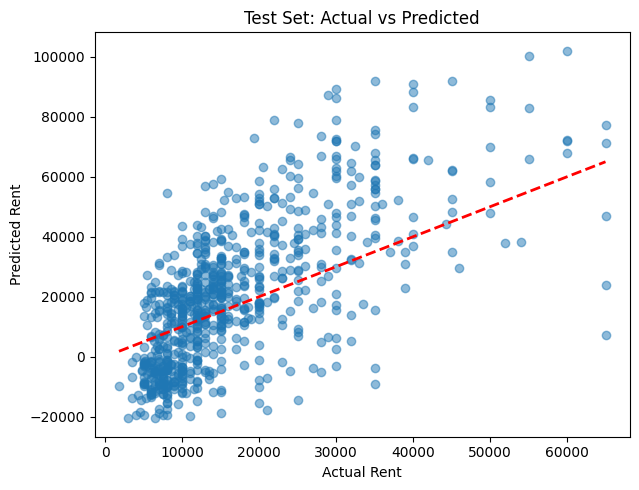

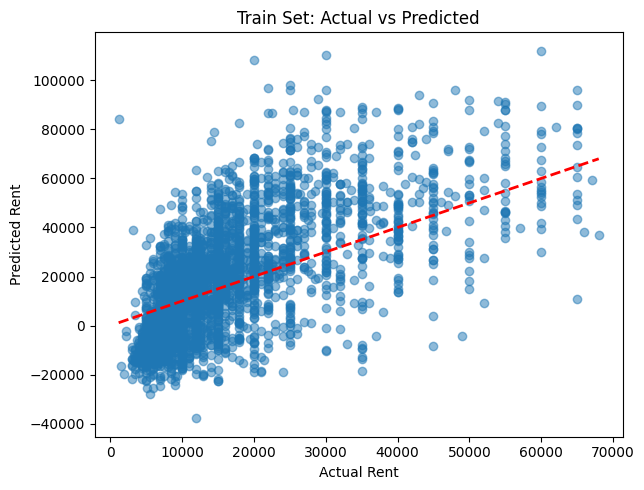

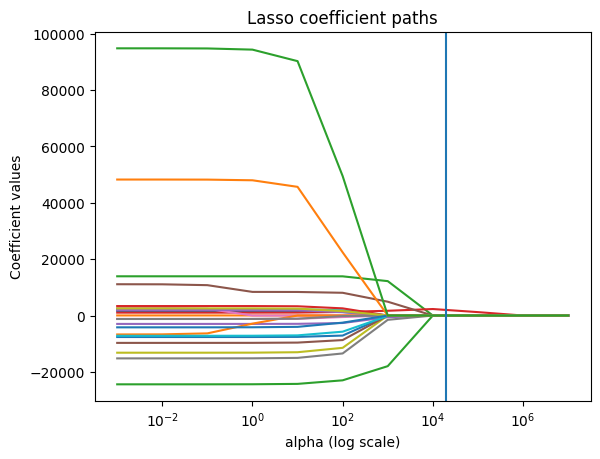

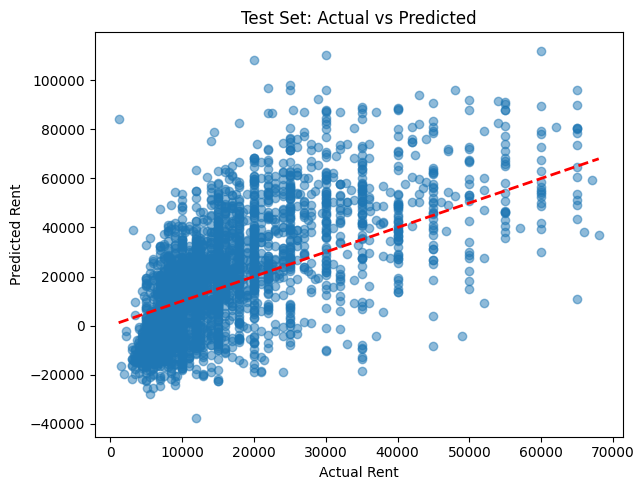

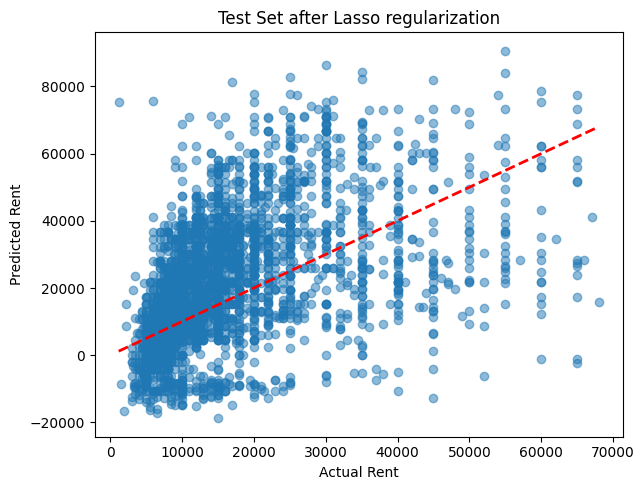

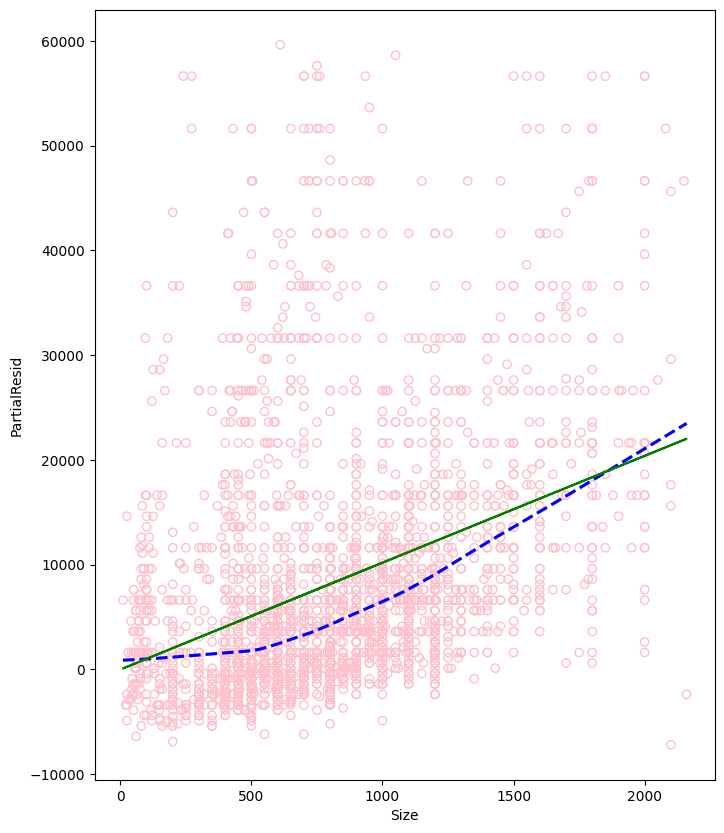

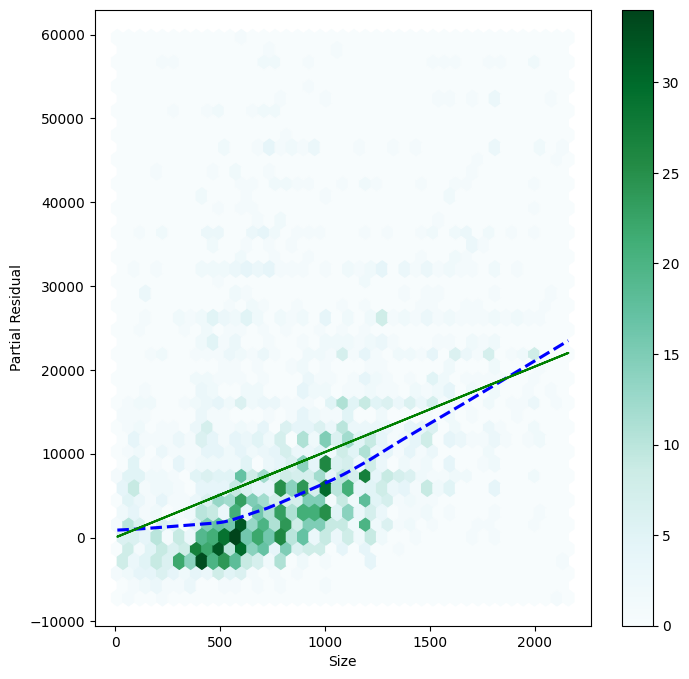

In [41]:
predictor1 = "Size"
X = house_clean[[predictor1]]   # predictor
y = house_clean['Rent']     # response variable

# add intercept
X = sm.add_constant(X)

# fit model
model = sm.OLS(y, X).fit()

# get partial residuals
# terms = b_i * X_i (without intercept)
terms = model.params[predictor1] * house_clean[predictor1]
partial_resid = model.resid + terms

# build dataframe for plotting
df = pd.DataFrame({
    predictor1: house_clean[predictor1],
    'Terms': terms,
    'PartialResid': partial_resid
})

# plotting
plt.figure(figsize=(8,10))
plt.scatter(x=df[predictor1], y=df['PartialResid'], facecolors='none', edgecolors='pink')

# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x=predictor1, y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df[predictor1], df['Terms'], color='green')




df.plot.hexbin(x=predictor1, y="PartialResid", gridsize=40, sharex=True, figsize=(8,8))

# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x=predictor1, y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df[predictor1], df['Terms'], color='green')

%matplotlib inline

plt.xlabel(predictor1)
plt.ylabel("Partial Residual")
plt.show()

In [42]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Rent   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     495.5
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          1.07e-101
Time:                        20:27:59   Log-Likelihood:                -32022.
No. Observations:                2994   AIC:                         6.405e+04
Df Residuals:                    2992   BIC:                         6.406e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8378.5909    427.052     19.620      0.000    7541.245    9215.937
Size          10.1941      0.458     22.259      0.000       9.296      11.092
==============================================================================
Omnibus:                     1174.875   Durbin-Watson:                   1.940
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4335.011
Skew:                           1.966   Prob(JB):                         0.00
Kurtosis:                       7.392   Cond. No.                     2.04e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [43]:
model.params
terms

1995     9684.384466
1497     8155.271129
2763     5555.778457
1351     4740.251344
1862     9174.680020
            ...     
2919      713.586224
3171     8155.271129
4426    15291.133367
466     12232.906694
860      4587.340010
Name: Size, Length: 2994, dtype: float64

In [44]:
model.resid

1995     5437.024649
1497    -6033.862014
2763     5065.630658
1351     6881.157771
1862     -553.270905
            ...     
2919     3907.822891
3171    -8533.862014
4426     1330.275748
466      -611.497579
860     12034.069105
Length: 2994, dtype: float64

<Axes: xlabel='Size', ylabel='Rent'>

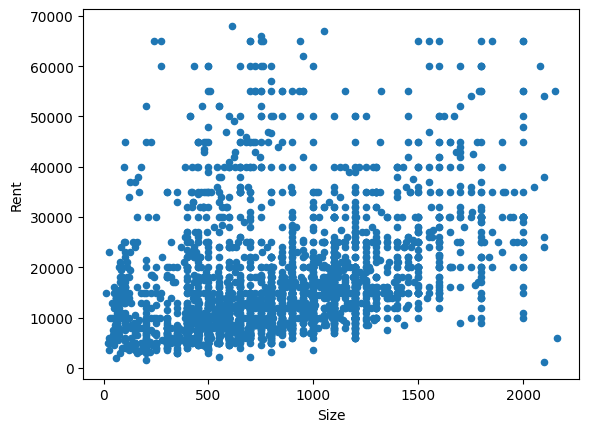

In [45]:
house_clean.plot.scatter(x="Size", y="Rent")

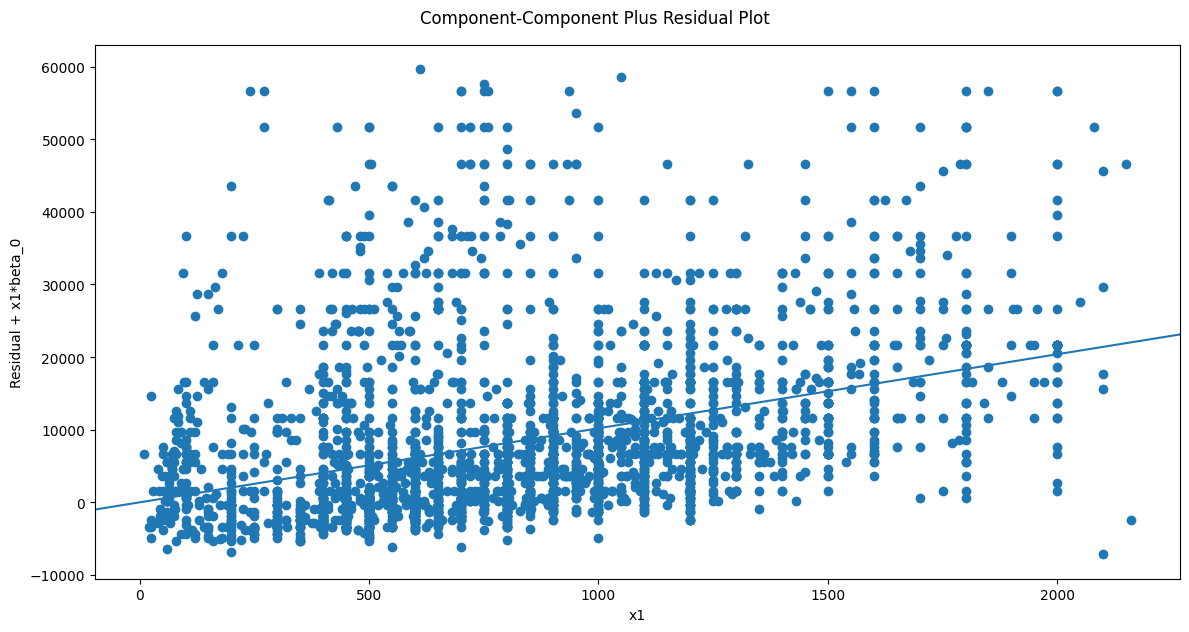

In [46]:
predictors = ['Size']
outcome = "Rent"


house_outlier = sm.OLS(house_clean[outcome].values, house_clean[predictors].assign(const=1).values)
model_OLS = house_outlier.fit()


fig = plt.figure(figsize=(12, 12))
fig = sm.graphics.plot_ccpr_grid(model_OLS, fig=fig)

In [47]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test Main model")
adjusted_r2(y_test, test_pred, 12)

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Main model Metrics:
MSE: 2115483795.95
RMSE: 45994.39
MAE: 21922.08
R2 Score: 0.4692
Adjusted r2: 0.4623911070415223

Cross-validation scores: [ 0.51581628  0.16185614  0.21878161  0.1778819  -1.1666998 ]
Average CV score: -0.0185 (+/- 1.1769)


In [48]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Month")
adjusted_r2(y_test, test_pred, 12)

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Month Metrics:
MSE: 2125952455.76
RMSE: 46108.05
MAE: 22037.06
R2 Score: 0.4666
Adjusted r2: 0.459730701593951

Cross-validation scores: [ 0.51380658  0.16086058  0.22240425  0.17734976 -1.20197652]
Average CV score: -0.0255 (+/- 1.2041)


In [49]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Floor group")
adjusted_r2(y_test, test_pred, 12)

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Floor group Metrics:
MSE: 2126924376.37
RMSE: 46118.59
MAE: 22152.78
R2 Score: 0.4663
Adjusted r2: 0.4594837069514198

Cross-validation scores: [ 0.51897013  0.16228852  0.21970666  0.17608864 -1.20233291]
Average CV score: -0.0251 (+/- 1.2058)


In [50]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Total floors")
adjusted_r2(y_test, test_pred, 12)

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Total floors Metrics:
MSE: 2164305396.36
RMSE: 46522.10
MAE: 22604.62
R2 Score: 0.4569
Adjusted r2: 0.44998405074439896

Cross-validation scores: [ 0.49350832  0.15601835  0.15462243  0.14382425 -1.24396711]
Average CV score: -0.0592 (+/- 1.2141)


In [51]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, 12)

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
MSE: 2150189081.78
RMSE: 46370.13
MAE: 22275.50
R2 Score: 0.4605
Adjusted r2: 0.4535714364139922

Cross-validation scores: [ 0.49922376  0.15808246  0.18849984  0.15980736 -1.09995452]
Average CV score: -0.0189 (+/- 1.1112)


In [52]:
# Create feature matrix X and target vector y
predictors = ['Size', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, 12)

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
MSE: 2277361088.52
RMSE: 47721.70
MAE: 22382.07
R2 Score: 0.4286
Adjusted r2: 0.421253154473313

Cross-validation scores: [ 0.44696046  0.13345911  0.27449788  0.14561873 -1.61059042]
Average CV score: -0.1220 (+/- 1.5056)
